<a href="https://colab.research.google.com/github/VikiTarasova/DTA_2026/blob/main/Homework/pandas_viz_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐼 Pandas + Matplotlib: практикум на 80 завдань

**Рівень:** середній (pandas) + початковий (matplotlib)

---

Цей зошит містить **80 завдань**:
- **50 завдань pandas** — поглиблюємо те, що вивчили, додаємо `loc`/`iloc`, `pivot_table`, складніший `groupby`
- **30 завдань візуалізації** — pandas `.plot()` + основи matplotlib з кольорами, стилями та легендами

## Дані
Працюємо з даними стрімінгового сервісу. Два файли:

**`streaming_subscribers.csv`** (600 рядків) — підписники сервісу:

| Стовпець | Опис |
|---|---|
| `subscriber_id` | Унікальний номер підписника |
| `age` | Вік |
| `gender` | Стать (Ч / Ж) |
| `country` | Країна (Україна, Польща, Німеччина, Чехія, Литва, Іспанія) |
| `plan` | Тариф (Basic / Standard / Premium / Family) |
| `monthly_fee` | Місячна плата (грн) |
| `join_date` | Дата реєстрації |
| `is_active` | Активний абонемент (Так / Ні) |

**`streaming_sessions.csv`** (5000 рядків) — сеанси перегляду:

| Стовпець | Опис |
|---|---|
| `session_id` | Унікальний номер сеансу |
| `subscriber_id` | ID підписника (зв'язок з першою таблицею) |
| `date` | Дата перегляду |
| `genre` | Жанр |
| `device` | Пристрій (Smart TV / Laptop / Mobile / Tablet) |
| `duration_min` | Тривалість перегляду в хвилинах |
| `rating` | Оцінка користувача (1-5) |

## Як працювати
- У кожній комірці є коментар з номером завдання — пишіть код під ним
- Запускайте кожну комірку (Shift + Enter), щоб бачити результат
- Якщо забули синтаксис — користуйтесь шпаргалкою з pandas та новою шпаргалкою matplotlib
- Не бійтесь експериментувати!

---

## Підготовка

Запустіть цю комірку — вона завантажує бібліотеки та дані. Усі завдання використовують змінні `subs` (підписники) та `sess` (сеанси).

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# subs = pd.read_csv("streaming_subscribers.csv")
# sess = pd.read_csv("streaming_sessions.csv")

subs = pd.read_csv("https://raw.githubusercontent.com/VikiTarasova/DTA_2026/refs/heads/main/Data/streaming_subscribers.csv")
sess = pd.read_csv("https://raw.githubusercontent.com/VikiTarasova/DTA_2026/refs/heads/main/Data/streaming_sessions.csv")

# Перетворюємо дати на справжній формат
subs["join_date"] = pd.to_datetime(subs["join_date"])
sess["date"] = pd.to_datetime(sess["date"])

print("Підписники:", subs.shape)
print("Сеанси:", sess.shape)
subs.head()

Підписники: (600, 8)
Сеанси: (5000, 7)


,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active
0,1001,19,Ч,Україна,Premium,329,2023-02-27,Ні
1,1002,40,Ж,Польща,Standard,219,2022-03-05,Так
2,1003,60,Ч,Україна,Basic,149,2023-02-20,Так
3,1004,36,Ч,Чехія,Basic,149,2022-02-22,Так
4,1005,34,Ж,Іспанія,Standard,219,2023-08-27,Так


---

# Частина 1. Pandas (50 завдань)

Розділи:
1. Розминка — повторення (1-8)
2. `loc` та `iloc` — вибірка за позиціями та мітками (9-18)
3. Складніший groupby (19-28)
4. `pivot_table` — зведені таблиці (29-36)
5. Робота з датами + обчислення (37-44)
6. Комбіновані завдання (45-50)

## Розділ 1.1. Розминка (завдання 1-8)

Швидке повторення того, що вже знаємо.

**Завдання 1.** Виведіть перші 10 рядків таблиці `sess`.

In [4]:
# Завдання 1:
sess.head(10)

,session_id,subscriber_id,date,genre,device,duration_min,rating
0,51573,1166,2024-04-11,Анімація,Mobile,72,1
1,50017,1429,2024-06-25,Романтика,Mobile,53,5
2,50861,1404,2024-07-05,Бойовик,Smart TV,49,5
3,54446,1520,2024-07-01,Серіал,Laptop,66,3
4,51561,1052,2024-06-13,Бойовик,Laptop,81,5
5,51938,1078,2024-08-27,Документальний,Mobile,60,4
6,52050,1343,2024-02-26,Бойовик,Tablet,86,3
7,54963,1444,2024-08-04,Серіал,Smart TV,56,4
8,50908,1521,2024-04-02,Драма,Smart TV,68,4
9,51976,1555,2024-04-11,Драма,Mobile,84,5


**Завдання 2.** Скільки всього підписників у даних? А сеансів?

> 💡 Атрибут `shape[0]` або функція `len()`.

In [5]:
# Завдання 2:
print("Підписників:", subs.shape[0])
print("Сеансів:", sess.shape[0])

Підписників: 600
Сеансів: 5000


**Завдання 3.** Виведіть кількість підписників по кожній країні. Відсортуйте за спаданням.

> 💡 `value_counts()` вже сортує за спаданням за замовчуванням.

In [6]:
# Завдання 3:
subs['country'].value_counts()

,count
country,
Україна,256
Німеччина,101
Польща,77
Чехія,68
Іспанія,62
Литва,36


**Завдання 4.** Знайдіть середній вік підписників.

In [7]:
# Завдання 4:
print("Середній вік підписників:", subs['age'].mean().round())
# subs['age'].mean()

Середній вік підписників: 43.0


**Завдання 5.** Знайдіть мінімальну та максимальну тривалість сеансу.

In [8]:
# Завдання 5:
print("MIN тривалість сеансу:", sess['duration_min'].min(), "хв.")
print("MAX тривалість сеансу:", sess['duration_min'].max(), "хв.")


MIN тривалість сеансу: 5 хв.
MAX тривалість сеансу: 171 хв.


**Завдання 6.** Скільки підписників активні (`is_active == "Так"`)?

In [9]:
# Завдання 6:
print("Aктивні:", len(subs[subs['is_active'] == "Так"]), "підписників")

Aктивні: 447 підписників


**Завдання 7.** Виведіть тільки сеанси з жанром `Драма` та оцінкою 5.

> 💡 Дві умови через `&`, кожна в дужках.

In [10]:
# Завдання 7:
sess[(sess['genre'] == 'Драма') & (sess['rating'] == 5)]

,session_id,subscriber_id,date,genre,device,duration_min,rating
9,51976,1555,2024-04-11,Драма,Mobile,84,5
68,51372,1447,2024-06-19,Драма,Tablet,93,5
74,53138,1074,2024-01-05,Драма,Laptop,48,5
94,52201,1124,2024-06-17,Драма,Laptop,34,5
117,53459,1454,2024-05-04,Драма,Mobile,77,5
...,...,...,...,...,...,...,...
4852,52566,1345,2024-03-28,Драма,Laptop,43,5
4855,51811,1579,2024-04-04,Драма,Smart TV,99,5
4902,53655,1551,2024-06-30,Драма,Laptop,48,5
4939,50494,1468,2024-01-30,Драма,Smart TV,36,5


**Завдання 8.** Створіть у таблиці `subs` новий стовпець `annual_fee` = `monthly_fee` × 12.

In [11]:
# Завдання 8:
subs['annual_fee'] = subs['monthly_fee'] * 12
subs.head(3)

,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee
0,1001,19,Ч,Україна,Premium,329,2023-02-27,Ні,3948
1,1002,40,Ж,Польща,Standard,219,2022-03-05,Так,2628
2,1003,60,Ч,Україна,Basic,149,2023-02-20,Так,1788


## Розділ 1.2. loc та iloc (завдання 9-18)

`iloc` працює за **числовими позиціями** (як індекси у списку):
- `df.iloc[0]` — перший рядок
- `df.iloc[0:5]` — рядки 0-4
- `df.iloc[0, 2]` — рядок 0, стовпець 2
- `df.iloc[:, 1:3]` — усі рядки, стовпці 1-2

`loc` працює за **мітками** (назвами):
- `df.loc[0]` — рядок з міткою 0
- `df.loc[df["age"] > 30, "country"]` — фільтр + конкретний стовпець
- `df.loc[df["plan"] == "Premium", ["age", "country"]]` — фільтр + кілька стовпців

**Завдання 9.** Виведіть перший рядок таблиці `subs` за допомогою `iloc`.

> 💡 `subs.iloc[0]`.

In [12]:
# Завдання 9:
subs.iloc[0]

,0
subscriber_id,1001
age,19
gender,Ч
country,Україна
plan,Premium
monthly_fee,329
join_date,2023-02-27 00:00:00
is_active,Ні
annual_fee,3948


**Завдання 10.** Виведіть рядки з 10 по 15 (включно) таблиці `subs` за допомогою `iloc`.

> 💡 `iloc[10:16]` (правий кінець не включається).

In [13]:
# Завдання 10:
subs.iloc[10:16]

,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee
10,1011,16,Ч,Іспанія,Family,449,2023-09-17,Так,5388
11,1012,56,Ч,Україна,Standard,219,2024-12-08,Так,2628
12,1013,25,Ч,Іспанія,Standard,219,2023-01-01,Так,2628
13,1014,17,Ч,Україна,Standard,219,2023-07-21,Так,2628
14,1015,55,Ж,Україна,Standard,219,2022-02-14,Ні,2628
15,1016,20,Ч,Польща,Premium,329,2022-06-09,Ні,3948


**Завдання 11.** Виведіть значення з 5-го рядка, 3-го стовпця таблиці `subs`.

> 💡 `iloc[5, 3]`. Нумерація з нуля!

In [14]:
# Завдання 11:
subs.iloc[5, 3]

'Польща'

**Завдання 12.** Виведіть перші 3 стовпці таблиці `sess` (усі рядки) за допомогою `iloc`.

> 💡 `iloc[:, :3]`.

In [15]:
# Завдання 12:
sess.iloc[:, :3]

,session_id,subscriber_id,date
0,51573,1166,2024-04-11
1,50017,1429,2024-06-25
2,50861,1404,2024-07-05
3,54446,1520,2024-07-01
4,51561,1052,2024-06-13
...,...,...,...
4995,52398,1356,2024-08-19
4996,51013,1208,2024-03-17
4997,54579,1174,2024-05-25
4998,52743,1431,2024-07-23


**Завдання 13.** Виведіть рядки 100-104, тільки стовпці `age` та `country`. Використайте `iloc`.

> 💡 `iloc[100:105, [1, 3]]` — індекси стовпців: age=1, country=3.

In [16]:
# Завдання 13:
subs.iloc[100:105, [1, 3]]

,age,country
100,63,Польща
101,21,Німеччина
102,62,Польща
103,48,Україна
104,54,Україна


**Завдання 14.** За допомогою `loc` виведіть тільки тих підписників, у яких вік більше 50. Поверніть тільки стовпці `country` та `plan`.

> 💡 `subs.loc[subs["age"] > 50, ["country", "plan"]]`.

In [17]:
# Завдання 14:
subs.loc[subs["age"] > 50, ["country", "plan"]]

,country,plan
2,Україна,Basic
11,Україна,Standard
14,Україна,Standard
16,Німеччина,Standard
18,Польща,Standard
...,...,...
593,Іспанія,Basic
594,Україна,Basic
595,Україна,Premium
598,Чехія,Standard


**Завдання 15.** За допомогою `loc` виведіть стовпець `monthly_fee` тільки для активних підписників (`is_active == "Так"`).

In [84]:
# Завдання 15:

subs.loc[subs["is_active"] == "Так", "monthly_fee"]

,monthly_fee
1,219
2,149
3,149
4,219
5,219
...,...
594,149
595,329
596,449
597,449


**Завдання 16.** Знайдіть середній вік підписників з тарифом `Premium`, використовуючи `loc`.

> 💡 `subs.loc[subs["plan"]=="Premium", "age"].mean()`.

In [85]:
# Завдання 16:
subs.loc[subs["plan"] == "Premium", "age"].mean()

np.float64(42.290780141843975)

**Завдання 17.** Використовуючи `loc`, ЗМІНІТЬ значення `is_active` на `"Так"` для підписника з `subscriber_id == 1001`.

> 💡 `subs.loc[subs["subscriber_id"]==1001, "is_active"] = "Так"`. Потім перевірте результат.

In [86]:
# Завдання 17:
# Змінюємо значення
subs.loc[subs["subscriber_id"] == 1001, "is_active"] = "Так"

# Перевіряємо результат
subs.loc[subs["subscriber_id"] == 1001, ["subscriber_id", "is_active"]]

,subscriber_id,is_active
0,1001,Так


**Завдання 18.** Виведіть останні 5 рядків таблиці `subs` за допомогою `iloc` (без `tail`).

> 💡 Від'ємні індекси: `iloc[-5:]`.

In [87]:
# Завдання 18:
subs.iloc[-5:]

,subscriber_id,age,gender,country,plan,monthly_fee,join_date,is_active,annual_fee
595,1596,53,Ж,Україна,Premium,329,2022-04-15,Так,3948
596,1597,30,Ч,Україна,Family,449,2024-03-26,Так,5388
597,1598,38,Ч,Німеччина,Family,449,2024-06-12,Так,5388
598,1599,64,Ж,Чехія,Standard,219,2024-05-03,Ні,2628
599,1600,68,Ч,Польща,Standard,219,2022-07-28,Так,2628


## Розділ 1.3. Складніший groupby (завдання 19-28)

Нові можливості:
- `.agg(["sum", "mean", "count"])` — кілька агрегатів одразу
- `.agg({"col1": "mean", "col2": "sum"})` — різні агрегати на різні стовпці
- `.transform("mean")` — повертає те саме число для кожного рядка групи (зручно для нових стовпців)
- `groupby(["col1", "col2"])` — групування за кількома стовпцями
- `.size()` — кількість рядків у кожній групі

**Завдання 19.** Для кожної країни виведіть кількість підписників та середній вік за один виклик `agg`.

> 💡 `subs.groupby("country").agg({"subscriber_id": "count", "age": "mean"})`.

In [88]:
# Завдання 19:
subs.groupby("country").agg(
    subscriber_count = ("subscriber_id", "count"),
    avg_age          = ("age",           "mean")
).round(2)

,subscriber_count,avg_age
country,,
Іспанія,62,43.08
Литва,36,40.42
Німеччина,101,45.10
Польща,77,42.96
Україна,256,43.57
Чехія,68,40.53


**Завдання 20.** Для кожного тарифу (`plan`) виведіть мінімальний, середній і максимальний вік підписників.

> 💡 `agg(["min", "mean", "max"])` на стовпці `age`.

In [89]:
# Завдання 20:
subs.groupby("plan")["age"].agg(["min", "mean", "max"]).round(2)

,min,mean,max
plan,,,
Basic,16,44.52,70
Family,16,41.93,70
Premium,16,42.29,70
Standard,16,43.38,70


**Завдання 21.** Для кожного жанру в таблиці `sess` порахуйте кількість сеансів та середню тривалість.

> 💡 `sess.groupby("genre").agg({"session_id": "count", "duration_min": "mean"})`.

In [95]:
# Завдання 21:
sess.groupby("genre").agg(
    session_count = ("session_id",   "count"),
    avg_duration  = ("duration_min", "mean")
).round(2)

,session_count,avg_duration
genre,,
Анімація,653,53.43
Бойовик,661,52.86
Документальний,573,52.66
Драма,578,52.86
Жахи,631,52.24
Комедія,629,54.13
Романтика,644,54.71
Серіал,631,53.95


**Завдання 22.** Для кожного пристрою порахуйте середню оцінку (`rating`) та середню тривалість (`duration_min`).

In [96]:
# Завдання 22:
sess.groupby("device").agg(
    avg_rating   = ("rating",       "mean"),
    avg_duration = ("duration_min", "mean")
).round(2)

,avg_rating,avg_duration
device,,
Laptop,3.98,52.85
Mobile,3.99,52.83
Smart TV,4.05,53.61
Tablet,4.01,55.38


**Завдання 23.** Згрупуйте сеанси за двома стовпцями: `genre` та `device`. Порахуйте середню оцінку.

> 💡 `groupby(["genre", "device"])["rating"].mean()`.

In [97]:
# Завдання 23:
sess.groupby(["genre", "device"])["rating"].mean().round(2)

genre           device  
Анімація        Laptop      3.91
                Mobile      4.07
                Smart TV    4.01
                Tablet      3.88
Бойовик         Laptop      4.08
                Mobile      3.81
                Smart TV    3.91
                Tablet      4.07
Документальний  Laptop      4.03
                Mobile      4.00
                Smart TV    4.12
                Tablet      3.98
Драма           Laptop      3.97
                Mobile      4.11
                Smart TV    4.11
                Tablet      4.20
Жахи            Laptop      3.96
                Mobile      3.99
                Smart TV    4.08
                Tablet      4.14
Комедія         Laptop      3.99
                Mobile      4.02
                Smart TV    4.02
                Tablet      3.97
Романтика       Laptop      4.00
                Mobile      3.92
                Smart TV    4.09
                Tablet      4.09
Серіал          Laptop      3.94
                Mobile      4.05
                Smart TV    4.10
                Tablet      3.72
Name: rating, dtype: float64

**Завдання 24.** Скільки сеансів припадає на кожну пару (`genre`, `device`)? Використайте `.size()`.

In [98]:
# Завдання 24:
sess.groupby(["genre", "device"]).size().unstack(fill_value=0)

device,Laptop,Mobile,Smart TV,Tablet
genre,,,,
Анімація,185,166,227,75
Бойовик,193,175,223,70
Документальний,175,136,214,48
Драма,154,158,207,59
Жахи,180,162,210,79
Комедія,184,154,233,58
Романтика,203,166,217,58
Серіал,185,166,220,60


**Завдання 25.** Додайте до таблиці `sess` новий стовпець `avg_rating_genre` — середня оцінка по жанру для цього сеансу. Використайте `.transform("mean")`.

> 💡 `sess["avg_rating_genre"] = sess.groupby("genre")["rating"].transform("mean")`.

In [99]:
# Завдання 25:
sess["avg_rating_genre"] = sess.groupby("genre")["rating"].transform("mean")

print(sess[["session_id", "genre", "rating", "avg_rating_genre"]].head(10))

   session_id           genre  rating  avg_rating_genre
0       51573        Анімація       1          3.981623
1       50017       Романтика       5          4.015528
2       50861         Бойовик       5          3.947050
3       54446          Серіал       3          4.001585
4       51561         Бойовик       5          3.947050
5       51938  Документальний       4          4.050611
6       52050         Бойовик       3          3.947050
7       54963          Серіал       4          4.001585
8       50908           Драма       4          4.079585
9       51976           Драма       5          4.079585


**Завдання 26.** Додайте до таблиці `subs` стовпець `avg_age_country` — середній вік підписників у країні цього підписника.

In [100]:
# Завдання 26:
subs["avg_age_country"] = subs.groupby("country")["age"].transform("mean")

print(subs[["subscriber_id", "country", "age", "avg_age_country"]].head(10))

   subscriber_id    country  age  avg_age_country
0           1001    Україна   19        43.566406
1           1002     Польща   40        42.961039
2           1003    Україна   60        43.566406
3           1004      Чехія   36        40.529412
4           1005    Іспанія   34        43.080645
5           1006     Польща   37        42.961039
6           1007    Україна   16        43.566406
7           1008  Німеччина   49        45.099010
8           1009  Німеччина   47        45.099010
9           1010  Німеччина   40        45.099010


**Завдання 27.** Знайдіть країну з найбільшим середнім віком підписників.

> 💡 `groupby + mean + idxmax()` АБО `sort_values(ascending=False).head(1)`.

In [101]:
# Завдання 27:
# Спосіб 1 — idxmax()
country_avg_age = subs.groupby("country")["age"].mean().round(2)
top_country = country_avg_age.idxmax()
print(f"Країна з найстаршими підписниками: {top_country} ({country_avg_age[top_country]} років)")

# Спосіб 2 — sort_values
country_avg_age.sort_values(ascending=False).head(1)

Країна з найстаршими підписниками: Німеччина (45.1 років)


,age
country,
Німеччина,45.1


**Завдання 28.** Для кожної країни порахуйте, скільки активних і скільки неактивних підписників. Використайте `groupby` за двома стовпцями + `size()`.

> 💡 `subs.groupby(["country", "is_active"]).size()`.

In [102]:
# Завдання 28:
result = subs.groupby(["country", "is_active"]).size().unstack(fill_value=0)
print(result)

is_active  Ні  Так
country           
Іспанія    16   46
Литва       7   29
Німеччина  29   72
Польща     21   56
Україна    66  190
Чехія      13   55


## Розділ 1.4. pivot_table — зведені таблиці (завдання 29-36)

`pivot_table` створює таблицю, де:
- `index` — що ставимо у рядки
- `columns` — що ставимо у стовпці
- `values` — що рахуємо
- `aggfunc` — який агрегат (за замовч. `"mean"`)

Приклад:
```python
pd.pivot_table(df, index="country", columns="plan", values="age", aggfunc="mean")
```


**Завдання 29.** Створіть зведену таблицю: рядки — `country`, стовпці — `plan`, значення — кількість підписників.

> 💡 `aggfunc="count"`, як `values` можна взяти `subscriber_id`.

In [103]:
# Завдання 29:
pd.pivot_table(
    subs,
    index="country",
    columns="plan",
    values="subscriber_id",
    aggfunc="count",
    fill_value=0
)

plan,Basic,Family,Premium,Standard
country,,,,
Іспанія,18,9,13,22
Литва,5,7,10,14
Німеччина,24,17,19,41
Польща,10,9,23,35
Україна,68,34,60,94
Чехія,13,16,16,23


**Завдання 30.** Зведена таблиця: рядки — `country`, стовпці — `plan`, значення — середній вік.

> 💡 `aggfunc="mean"` (за замовчуванням).

In [104]:
# Завдання 30:
pd.pivot_table(
    subs,
    index="country",
    columns="plan",
    values="age",
    aggfunc="mean"
).round(2)

plan,Basic,Family,Premium,Standard
country,,,,
Іспанія,42.83,38.56,45.38,43.77
Литва,39.00,42.86,37.60,41.71
Німеччина,46.79,46.24,42.26,44.95
Польща,45.40,40.11,38.87,45.69
Україна,45.03,41.44,44.75,42.52
Чехія,41.46,40.94,38.44,41.17


**Завдання 31.** Зведена таблиця по сеансах: рядки — `genre`, стовпці — `device`, значення — середня оцінка.

In [105]:
# Завдання 31:
pd.pivot_table(
    sess,
    index="genre",
    columns="device",
    values="rating",
    aggfunc="mean"
).round(2)

device,Laptop,Mobile,Smart TV,Tablet
genre,,,,
Анімація,3.91,4.07,4.01,3.88
Бойовик,4.08,3.81,3.91,4.07
Документальний,4.03,4.00,4.12,3.98
Драма,3.97,4.11,4.11,4.20
Жахи,3.96,3.99,4.08,4.14
Комедія,3.99,4.02,4.02,3.97
Романтика,4.00,3.92,4.09,4.09
Серіал,3.94,4.05,4.10,3.72


**Завдання 32.** Зведена таблиця: рядки — `genre`, стовпці — `device`, значення — сумарна тривалість сеансів.

> 💡 `aggfunc="sum"`.

In [106]:
# Завдання 32:
pd.pivot_table(
    sess,
    index="genre",
    columns="device",
    values="duration_min",
    aggfunc="sum",
    fill_value=0
).round(2)

device,Laptop,Mobile,Smart TV,Tablet
genre,,,,
Анімація,9358,8700,12457,4375
Бойовик,10023,9625,11471,3819
Документальний,9116,6731,11690,2636
Драма,8050,8391,10806,3307
Жахи,9479,8513,11095,3877
Комедія,10208,8427,12034,3376
Романтика,10659,8610,12685,3280
Серіал,10221,8778,11640,3406


**Завдання 33.** Зведена таблиця: рядки — `country`, стовпці — `gender`, значення — кількість підписників.

In [107]:
# Завдання 33:
pd.pivot_table(
    subs,
    index="country",
    columns="gender",
    values="subscriber_id",
    aggfunc="count",
    fill_value=0,
    margins=True,
    margins_name="Total"
)


gender,Ж,Ч,Total
country,,,
Іспанія,32,30,62
Литва,22,14,36
Німеччина,51,50,101
Польща,40,37,77
Україна,132,124,256
Чехія,36,32,68
Total,313,287,600


**Завдання 34.** Зведена таблиця: рядки — `plan`, стовпці — `is_active`, значення — кількість підписників.

In [108]:
# Завдання 34:
pd.pivot_table(
    subs,
    index="plan",
    columns="is_active",
    values="subscriber_id",
    aggfunc="count",
    fill_value=0,
    margins=True,
    margins_name="Total"
)

is_active,Ні,Так,Total
plan,,,
Basic,35,103,138
Family,26,66,92
Premium,41,100,141
Standard,50,179,229
Total,152,448,600


**Завдання 35.** Створіть зведену таблицю по сеансах: `genre` у рядках, `device` у стовпцях, кількість сеансів. Заповніть пропуски нулями.

> 💡 Параметр `fill_value=0`.

In [109]:
# Завдання 35:
pd.pivot_table(
    sess,
    index="genre",
    columns="device",
    values="session_id",
    aggfunc="count",
    fill_value=0
)

device,Laptop,Mobile,Smart TV,Tablet
genre,,,,
Анімація,185,166,227,75
Бойовик,193,175,223,70
Документальний,175,136,214,48
Драма,154,158,207,59
Жахи,180,162,210,79
Комедія,184,154,233,58
Романтика,203,166,217,58
Серіал,185,166,220,60


**Завдання 36.** Зведена таблиця: рядки — `country`, значення — кількість підписників та середній `monthly_fee` одночасно.

> 💡 `values=["subscriber_id", "monthly_fee"]` плюс `aggfunc={"subscriber_id":"count", "monthly_fee":"mean"}`.

In [110]:
# Завдання 36:
pd.pivot_table(
    subs,
    index="country",
    values=["subscriber_id", "monthly_fee"],
    aggfunc={
        "subscriber_id": "count",
        "monthly_fee":   "mean"
    }
).round(2).rename(columns={
    "subscriber_id": "subscriber_count",
    "monthly_fee":   "avg_monthly_fee"
})


,avg_monthly_fee,subscriber_count
country,,
Іспанія,255.13,62
Литва,284.56,36
Німеччина,261.77,101
Польща,269.65,77
Україна,256.73,256
Чехія,285.62,68


## Розділ 1.5. Робота з датами + обчислення (завдання 37-44)

Нагадування: дати вже перетворено на datetime у комірці підготовки.
- `.dt.year`, `.dt.month`, `.dt.day` — частини дати
- `.dt.day_name()` — назва дня тижня
- Можна віднімати дати: `df["date1"] - df["date2"]` (отримуємо тривалість)

**Завдання 37.** Додайте до таблиці `sess` стовпець `month` — місяць сеансу.

In [111]:
# Завдання 37:
sess["month"] = sess["date"].dt.month

print(sess[["session_id", "date", "month"]].head(8))

   session_id       date  month
0       51573 2024-04-11      4
1       50017 2024-06-25      6
2       50861 2024-07-05      7
3       54446 2024-07-01      7
4       51561 2024-06-13      6
5       51938 2024-08-27      8
6       52050 2024-02-26      2
7       54963 2024-08-04      8


**Завдання 38.** Додайте до таблиці `sess` стовпець `weekday` — назву дня тижня.

> 💡 `.dt.day_name()`.

In [112]:
# Завдання 38:
sess["weekday"] = sess["date"].dt.day_name()

print(sess[["session_id", "date", "weekday"]].head(8))


   session_id       date   weekday
0       51573 2024-04-11  Thursday
1       50017 2024-06-25   Tuesday
2       50861 2024-07-05    Friday
3       54446 2024-07-01    Monday
4       51561 2024-06-13  Thursday
5       51938 2024-08-27   Tuesday
6       52050 2024-02-26    Monday
7       54963 2024-08-04    Sunday


**Завдання 39.** Скільки сеансів припадає на кожен місяць? Відсортуйте за номером місяця.

> 💡 `groupby("month")` + `size()` або `count`.

In [113]:
# Завдання 39:
sess.groupby("month").size().sort_index()

,0
month,
1,667
2,627
3,627
4,601
5,635
6,599
7,664
8,580


**Завдання 40.** У який день тижня користувачі переглядають найбільше? Згрупуйте за `weekday`, порахуйте кількість сеансів.

In [114]:
# Завдання 40:
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

result = (
    sess.groupby("weekday")
    .size()
    .reindex(days_order)
    .reset_index()
)
result.columns = ["weekday", "session_count"]
top_day = result.loc[result["session_count"].idxmax(), "weekday"]

print(result)
print(f"\nНайпопулярніший день: {top_day}")

     weekday  session_count
0     Monday            736
1    Tuesday            708
2  Wednesday            726
3   Thursday            713
4     Friday            706
5   Saturday            719
6     Sunday            692

Найпопулярніший день: Monday


**Завдання 41.** Скільки сеансів відбулось у червні 2024? Відфільтруйте, потім порахуйте.

> 💡 `sess[sess["date"].dt.month == 6]` (бо всі дані за 2024 рік).

In [115]:
# Завдання 41:
# Фільтр по місяцю та року
june_2024 = sess[
    (sess["date"].dt.month == 6) &
    (sess["date"].dt.year  == 2024)
]

print(f"Сеансів у червні 2024: {len(june_2024)}")
print(f"\nРозбивка по жанрах:")
print(june_2024["genre"].value_counts())
print(f"\nРозбивка по пристроях:")
print(june_2024["device"].value_counts())

Сеансів у червні 2024: 599

Розбивка по жанрах:
genre
Бойовик           91
Романтика         83
Документальний    76
Серіал            74
Анімація          73
Драма             68
Жахи              68
Комедія           66
Name: count, dtype: int64

Розбивка по пристроях:
device
Smart TV    217
Laptop      185
Mobile      137
Tablet       60
Name: count, dtype: int64


**Завдання 42.** Додайте до таблиці `subs` стовпець `years_with_us` — скільки років підписник з нами (різниця між 2024-12-31 та `join_date` у роках).

> 💡 `(pd.Timestamp("2024-12-31") - subs["join_date"]).dt.days / 365` — округліть як хочете.

In [116]:
# Завдання 42:
end_date = pd.Timestamp("2024-12-31")

subs["years_with_us"] = (
    (end_date - subs["join_date"]).dt.days / 365
).round(2)

print(subs[["subscriber_id", "join_date", "years_with_us"]].head(8))
print(f"\nСередній термін підписки: {subs['years_with_us'].mean():.2f} років")
print(f"Найдовший: {subs['years_with_us'].max():.2f} років")
print(f"Найкоротший: {subs['years_with_us'].min():.2f} років")

   subscriber_id  join_date  years_with_us
0           1001 2023-02-27           1.84
1           1002 2022-03-05           2.83
2           1003 2023-02-20           1.86
3           1004 2022-02-22           2.86
4           1005 2023-08-27           1.35
5           1006 2024-11-17           0.12
6           1007 2024-07-22           0.44
7           1008 2022-11-06           2.15

Середній термін підписки: 1.54 років
Найдовший: 3.00 років
Найкоротший: 0.01 років


**Завдання 43.** Скільки нових підписників прийшло у кожному році (за `join_date`)? Згрупуйте за роком.

> 💡 `subs["join_date"].dt.year` + `value_counts`.

In [117]:
# Завдання 43:
result = (
    subs["join_date"].dt.year
    .value_counts()
    .sort_index()
    .reset_index()
)
result.columns = ["year", "new_subscribers"]

print(result)
print(f"\nНайкращий рік: {result.loc[result['new_subscribers'].idxmax(), 'year']}")

   year  new_subscribers
0  2022              209
1  2023              208
2  2024              183

Найкращий рік: 2022


**Завдання 44.** Знайдіть місяць 2024 року, коли було найбільше переглядів. Виведіть номер місяця та кількість сеансів.

In [118]:
# Завдання 44:
result = (
    sess[sess["date"].dt.year == 2024]
    .groupby(sess["date"].dt.month)
    .size()
    .reset_index()
)
result.columns = ["month", "session_count"]

best_month = result.loc[result["session_count"].idxmax()]

print(result)
print(f"\nНайкращий місяць: {int(best_month['month'])} — {int(best_month['session_count'])} сеансів")

   month  session_count
0      1            667
1      2            627
2      3            627
3      4            601
4      5            635
5      6            599
6      7            664
7      8            580

Найкращий місяць: 1 — 667 сеансів


## Розділ 1.6. Комбіновані завдання (завдання 45-50)

Найскладніші — поєднують різні концепції.

**Завдання 45.** Знайдіть топ-5 підписників за СУМАРНОЮ тривалістю переглядів. Виведіть `subscriber_id` та сумарну тривалість.

> 💡 Згрупуйте `sess` за `subscriber_id`, порахуйте суму `duration_min`, відсортуйте, візьміть head(5).

In [119]:
# Завдання 45:
top5_subscribers = (
    sess.groupby("subscriber_id")["duration_min"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)
top5_subscribers.columns = ["subscriber_id", "total_duration_min"]

# Додати години для зручності
top5_subscribers["total_duration_hrs"] = (
    top5_subscribers["total_duration_min"] / 60
).round(2)

print(top5_subscribers)

   subscriber_id  total_duration_min  total_duration_hrs
0           1020                1184               19.73
1           1549                1165               19.42
2           1479                1138               18.97
3           1535                1081               18.02
4           1252                1019               16.98


**Завдання 46.** Для кожного жанру знайдіть відсоток сеансів від загальної кількості сеансів.

> 💡 `value_counts(normalize=True) * 100` АБО `groupby + size`, поділене на `len(sess)`, * 100.

In [121]:
# Завдання 46:
# Спосіб 1 — value_counts
result = (
    sess["genre"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)
result.columns = ["genre", "share_pct"]
print(result)

            genre  share_pct
0         Бойовик      13.22
1        Анімація      13.06
2       Романтика      12.88
3          Серіал      12.62
4            Жахи      12.62
5         Комедія      12.58
6           Драма      11.56
7  Документальний      11.46


**Завдання 47.** Знайдіть жанр, який має найвищу середню оцінку (`rating`).

> 💡 `groupby + mean + idxmax`.

In [123]:
# Завдання 47:
genre_rating = (
    sess.groupby("genre")["rating"]
    .mean()
    .round(2)
)

best_genre = genre_rating.idxmax()
print(f"Найкращий жанр: {best_genre} ({genre_rating[best_genre]})")
print(f"\nРейтинг по всіх жанрах:")
print(genre_rating.sort_values(ascending=False))

Найкращий жанр: Драма (4.08)

Рейтинг по всіх жанрах:
genre
Драма             4.08
Документальний    4.05
Жахи              4.03
Романтика         4.02
Комедія           4.01
Серіал            4.00
Анімація          3.98
Бойовик           3.95
Name: rating, dtype: float64


**Завдання 48.** Скільки сеансів у кожній країні? Підказка: треба об'єднати дві таблиці.

> 💡 Використайте `merge`: `sess.merge(subs[["subscriber_id", "country"]], on="subscriber_id")`, потім `groupby("country").size()`.

In [124]:
# Завдання 48:
result = (
    sess.merge(subs[["subscriber_id", "country"]], on="subscriber_id", how="left")
    .groupby("country")
    .size()
    .reset_index(name="session_count")
    .sort_values("session_count", ascending=False)
)

print(result)

     country  session_count
4    Україна           2114
2  Німеччина            857
3     Польща            626
5      Чехія            562
0    Іспанія            520
1      Литва            321


**Завдання 49.** Який тариф (`plan`) дає найбільшу СЕРЕДНЮ тривалість сеансу? Об'єднайте таблиці, потім згрупуйте.

> 💡 `sess.merge(subs[["subscriber_id","plan"]], on="subscriber_id")` потім `groupby("plan")["duration_min"].mean()`.

In [126]:
# Завдання 49:
result = (
    sess.merge(subs[["subscriber_id", "plan"]], on="subscriber_id", how="left")
    .groupby("plan")["duration_min"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

best_plan = result.idxmax()
print(f"Тариф з найдовшими сеансами: {best_plan} ({result[best_plan]} хв)")
print(f"\nСередня тривалість по тарифах:")
print(result)

Тариф з найдовшими сеансами: Family (69.15 хв)

Середня тривалість по тарифах:
plan
Family      69.15
Premium     64.74
Standard    49.95
Basic       36.98
Name: duration_min, dtype: float64


**Завдання 50.** Для кожної країни знайдіть популярний жанр (з найбільшою кількістю сеансів).

> 💡 Об'єднайте таблиці, згрупуйте за `["country", "genre"]`, порахуйте `size`, потім для кожної країни знайдіть жанр з максимумом. Підказка: можна `.groupby("country").idxmax()`.

In [127]:
# Завдання 50:
merged = sess.merge(subs[["subscriber_id", "country"]], on="subscriber_id", how="left")

# Кількість сеансів по країні та жанру
country_genre = (
    merged.groupby(["country", "genre"])
    .size()
    .reset_index(name="session_count")
)

# Найпопулярніший жанр для кожної країни
top_genre = (
    country_genre.loc[
        country_genre.groupby("country")["session_count"].idxmax()
    ]
    .reset_index(drop=True)
)

print(top_genre)

     country      genre  session_count
0    Іспанія  Романтика             77
1      Литва       Жахи             46
2  Німеччина    Комедія            122
3     Польща  Романтика             87
4    Україна    Бойовик            308
5      Чехія     Серіал             86


---

# Частина 2. Візуалізація (30 завдань)

Розділи:
1. Швидкі графіки через pandas `.plot()` (51-58)
2. Основні типи matplotlib (59-66)
3. Налаштування графіків — заголовки, осі, кольори (67-74)
4. Легенди, кілька серій, subplots (75-80)

> 💡 **Загальне правило:** після кожного `plt....` коду додавайте `plt.show()` — це показує графік.

## Розділ 2.1. Швидкі графіки через pandas (завдання 51-58)

pandas вміє будувати швидкі графіки прямо з даних — метод `.plot()`. Це найшвидший спосіб подивитись на дані.

Параметри:
- `kind="bar"` — стовпчаста діаграма
- `kind="barh"` — горизонтальна стовпчаста
- `kind="line"` — лінійна (за замовчуванням)
- `kind="hist"` — гістограма
- `kind="pie"` — кругова
- `kind="scatter"` — точкова (треба вказати `x` і `y`)
- `title="..."` — заголовок

**Завдання 51.** Побудуйте стовпчасту діаграму кількості підписників по країнах.

> 💡 `subs["country"].value_counts().plot(kind="bar")` + `plt.show()`.

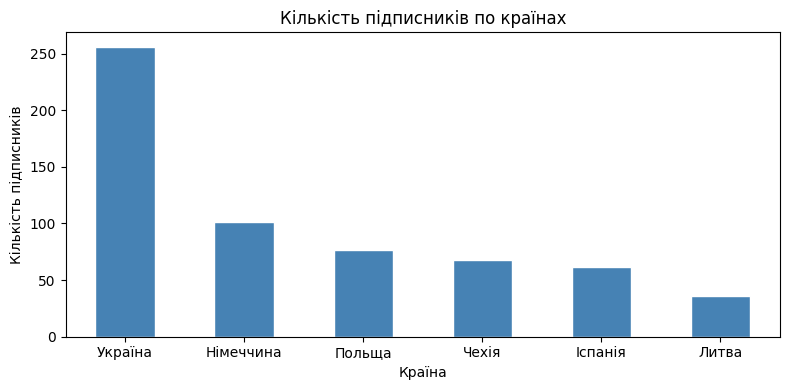

In [128]:
# Завдання 51:
subs["country"].value_counts().plot(
    kind="bar",
    title="Кількість підписників по країнах",
    color="steelblue",
    edgecolor="white",
    figsize=(8, 4)
)

plt.xlabel("Країна")
plt.ylabel("Кількість підписників")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Завдання 52.** Побудуйте кругову діаграму (`pie`) розподілу підписників за тарифами.

> 💡 `value_counts().plot(kind="pie")`.

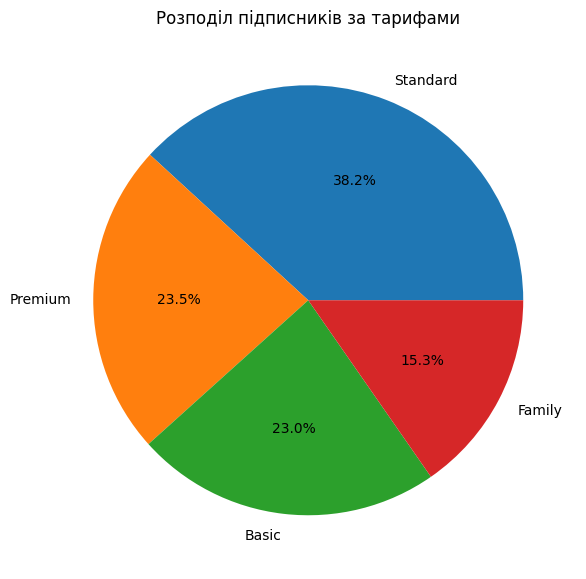

In [129]:
# Завдання 52:
subs["plan"].value_counts().plot(
    kind="pie",
    title="Розподіл підписників за тарифами",
    autopct="%1.1f%%",
    figsize=(6, 6)
)

plt.ylabel("")
plt.tight_layout()
plt.show()

**Завдання 53.** Побудуйте гістограму розподілу віку підписників.

> 💡 `subs["age"].plot(kind="hist")`.

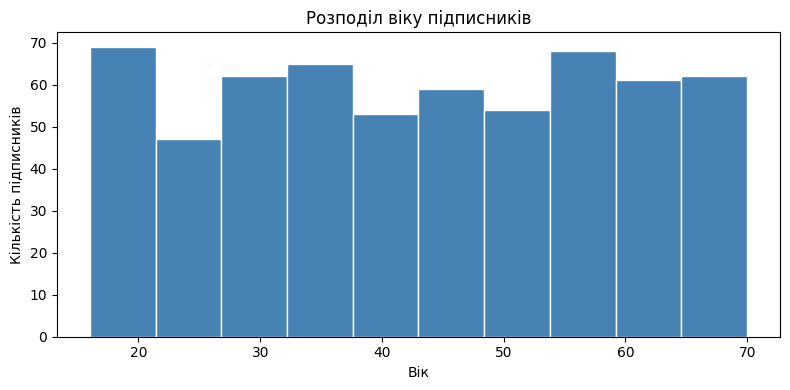

In [130]:
# Завдання 53:
subs["age"].plot(
    kind="hist",
    bins=10,
    title="Розподіл віку підписників",
    color="steelblue",
    edgecolor="white",
    figsize=(8, 4)
)

plt.xlabel("Вік")
plt.ylabel("Кількість підписників")
plt.tight_layout()
plt.show()

**Завдання 54.** Побудуйте гістограму тривалості сеансів з 20 інтервалами (bins).

> 💡 Параметр `bins=20`.

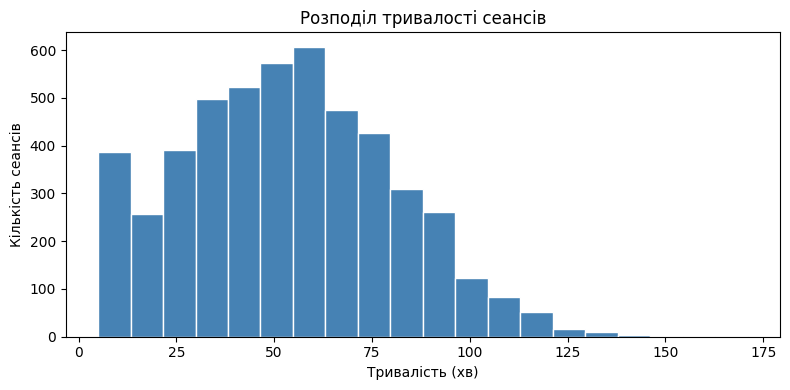

In [131]:
# Завдання 54:
sess["duration_min"].plot(
    kind="hist",
    bins=20,
    title="Розподіл тривалості сеансів",
    color="steelblue",
    edgecolor="white",
    figsize=(8, 4)
)

plt.xlabel("Тривалість (хв)")
plt.ylabel("Кількість сеансів")
plt.tight_layout()
plt.show()

**Завдання 55.** Побудуйте лінійну діаграму кількості сеансів по місяцях. Спочатку згрупуйте за місяцем, потім `.plot()`.

> 💡 `sess.groupby("month").size().plot()`.

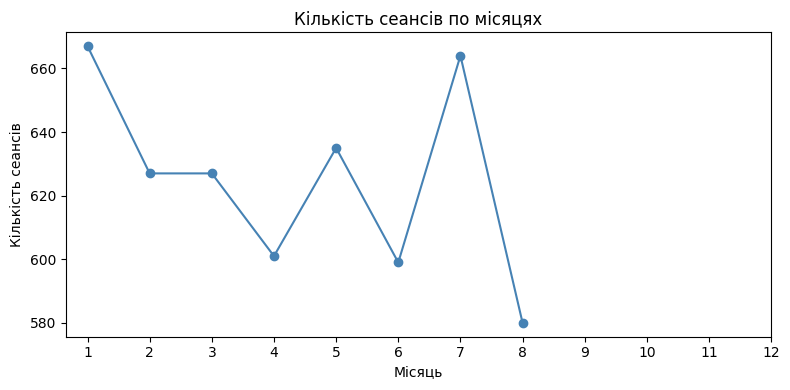

In [132]:
# Завдання 55:
sess.groupby("month").size().plot(
    kind="line",
    title="Кількість сеансів по місяцях",
    color="steelblue",
    marker="o",
    figsize=(8, 4)
)

plt.xlabel("Місяць")
plt.ylabel("Кількість сеансів")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

**Завдання 56.** Побудуйте горизонтальну стовпчасту діаграму кількості сеансів по жанрах.

> 💡 `kind="barh"`.

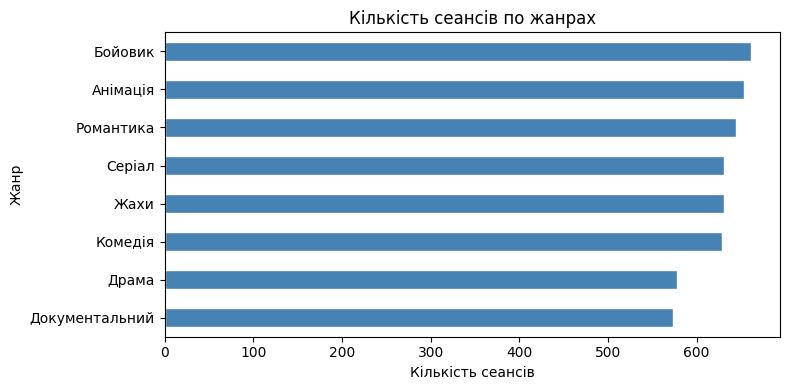

In [133]:
# Завдання 56:
sess.groupby("genre").size().sort_values().plot(
    kind="barh",
    title="Кількість сеансів по жанрах",
    color="steelblue",
    edgecolor="white",
    figsize=(8, 4)
)

plt.xlabel("Кількість сеансів")
plt.ylabel("Жанр")
plt.tight_layout()
plt.show()

**Завдання 57.** Побудуйте стовпчасту діаграму середньої оцінки (`rating`) по жанрах.

> 💡 `groupby("genre")["rating"].mean().plot(kind="bar")`.

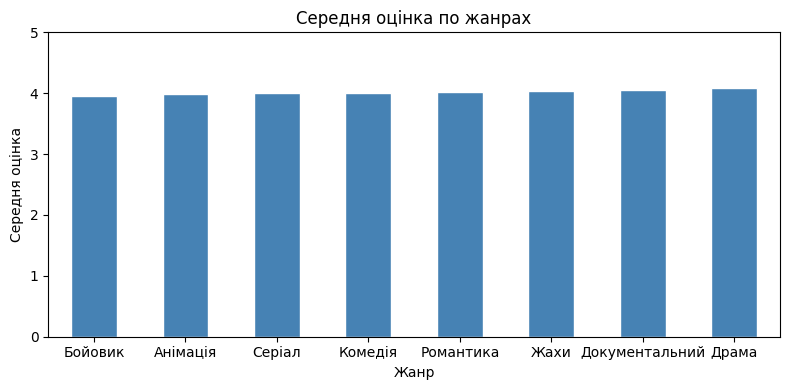

In [134]:
# Завдання 57:
sess.groupby("genre")["rating"].mean().sort_values().plot(
    kind="bar",
    title="Середня оцінка по жанрах",
    color="steelblue",
    edgecolor="white",
    figsize=(8, 4)
)

plt.xlabel("Жанр")
plt.ylabel("Середня оцінка")
plt.ylim(0, 5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Завдання 58.** Побудуйте scatter plot (точкову): по осі X — `duration_min`, по осі Y — `rating` (з таблиці `sess`).

> 💡 `sess.plot(kind="scatter", x="duration_min", y="rating")`.

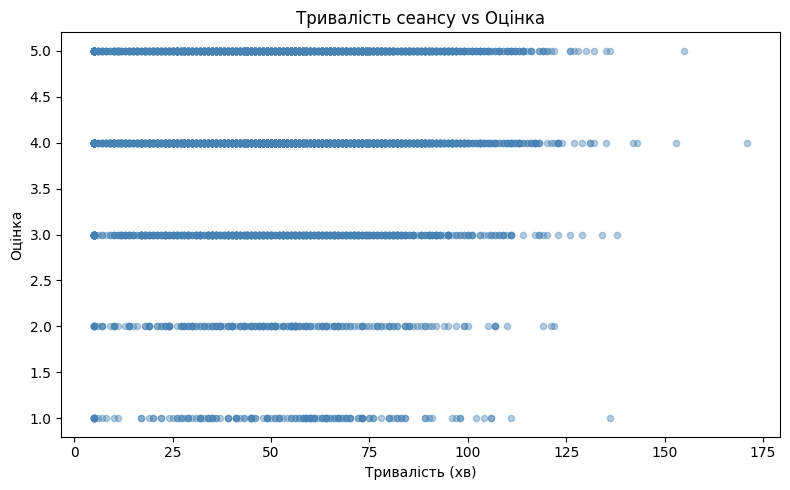

In [135]:
# Завдання 58:
sess.plot(
    kind="scatter",
    x="duration_min",
    y="rating",
    title="Тривалість сеансу vs Оцінка",
    color="steelblue",
    alpha=0.4,
    figsize=(8, 5)
)

plt.xlabel("Тривалість (хв)")
plt.ylabel("Оцінка")
plt.tight_layout()
plt.show()

## Розділ 2.2. Основи matplotlib (завдання 59-66)

matplotlib дає більше контролю. Базовий синтаксис:

```python
plt.figure(figsize=(8, 5))   # розмір графіка
plt.bar(категорії, значення) # bar / line / scatter / hist
plt.title("Заголовок")
plt.xlabel("Назва X")
plt.ylabel("Назва Y")
plt.show()
```

Функції: `plt.bar()`, `plt.barh()`, `plt.plot()`, `plt.hist()`, `plt.scatter()`, `plt.pie()`.

**Завдання 59.** Створіть стовпчасту діаграму через `plt.bar()`. По осі X — країни, по осі Y — кількість підписників.

> 💡 Спочатку отримайте дані: `counts = subs["country"].value_counts()`. Потім: `plt.bar(counts.index, counts.values)`.

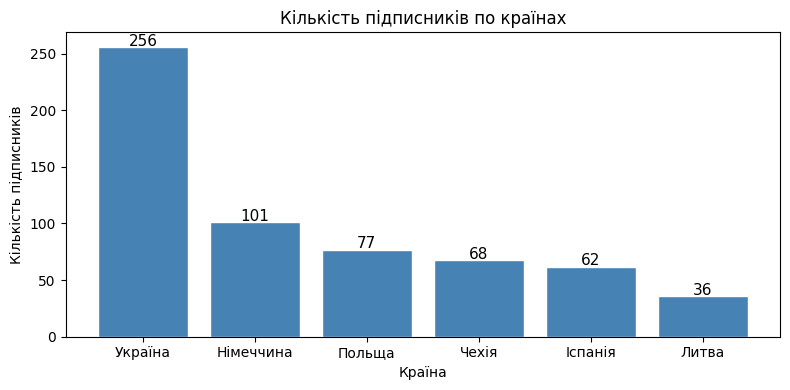

In [136]:
# Завдання 59:
counts = subs["country"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(counts.index, counts.values, color="steelblue", edgecolor="white")

plt.title("Кількість підписників по країнах")
plt.xlabel("Країна")
plt.ylabel("Кількість підписників")

# Підписи значень над стовпцями
for i, v in enumerate(counts.values):
    plt.text(i, v + 1, str(v), ha="center", fontsize=11)

plt.tight_layout()
plt.show()

**Завдання 60.** Створіть лінійну діаграму через `plt.plot()`: динаміка кількості сеансів по місяцях.

> 💡 `monthly = sess.groupby("month").size()` + `plt.plot(monthly.index, monthly.values)`.

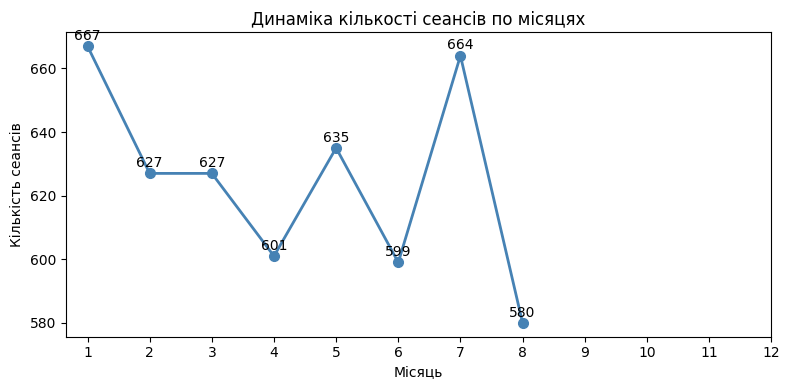

In [137]:
# Завдання 60:
monthly = sess.groupby("month").size()

plt.figure(figsize=(8, 4))
plt.plot(monthly.index, monthly.values,
         color="steelblue", marker="o", linewidth=2, markersize=7)

plt.title("Динаміка кількості сеансів по місяцях")
plt.xlabel("Місяць")
plt.ylabel("Кількість сеансів")
plt.xticks(range(1, 13))

# Підписи значень над точками
for x, y in zip(monthly.index, monthly.values):
    plt.text(x, y + 2, str(y), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

**Завдання 61.** Створіть гістограму віку підписників через `plt.hist()` з 15 інтервалами.

> 💡 `plt.hist(subs["age"], bins=15)`.

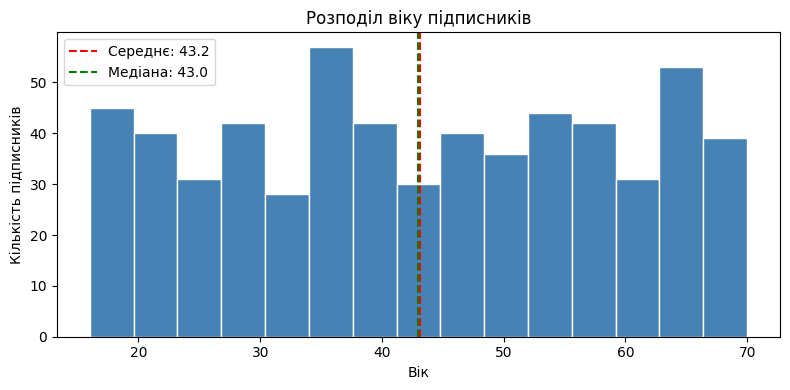

In [138]:
# Завдання 61:
plt.figure(figsize=(8, 4))
plt.hist(subs["age"], bins=15, color="steelblue", edgecolor="white")

plt.title("Розподіл віку підписників")
plt.xlabel("Вік")
plt.ylabel("Кількість підписників")

# Лінії середнього та медіани
plt.axvline(subs["age"].mean(),   color="red",   linestyle="--",
            linewidth=1.5, label=f"Середнє: {subs['age'].mean():.1f}")
plt.axvline(subs["age"].median(), color="green", linestyle="--",
            linewidth=1.5, label=f"Медіана: {subs['age'].median():.1f}")

plt.legend()
plt.tight_layout()
plt.show()

**Завдання 62.** Створіть точкову діаграму через `plt.scatter()`: вік підписників по X, місячна плата по Y.

> 💡 `plt.scatter(subs["age"], subs["monthly_fee"])`.

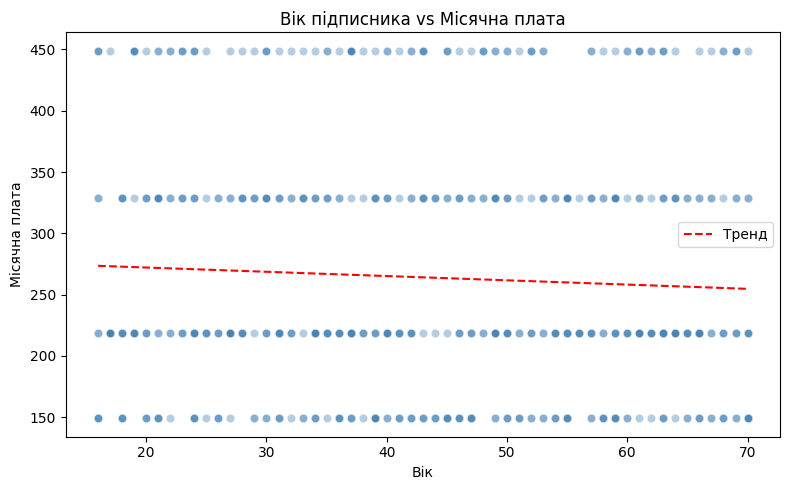

In [139]:
# Завдання 62:
plt.figure(figsize=(8, 5))
plt.scatter(subs["age"], subs["monthly_fee"],
            color="steelblue", alpha=0.4, edgecolors="white", linewidths=0.5)

plt.title("Вік підписника vs Місячна плата")
plt.xlabel("Вік")
plt.ylabel("Місячна плата")

# Лінія тренду
import numpy as np
z = np.polyfit(subs["age"], subs["monthly_fee"], 1)
p = np.poly1d(z)
x_line = np.linspace(subs["age"].min(), subs["age"].max(), 100)
plt.plot(x_line, p(x_line), color="red", linestyle="--",
         linewidth=1.5, label="Тренд")

plt.legend()
plt.tight_layout()
plt.show()

**Завдання 63.** Створіть кругову діаграму через `plt.pie()`: розподіл сеансів за пристроями.

> 💡 `counts = sess["device"].value_counts()` + `plt.pie(counts.values, labels=counts.index)`.

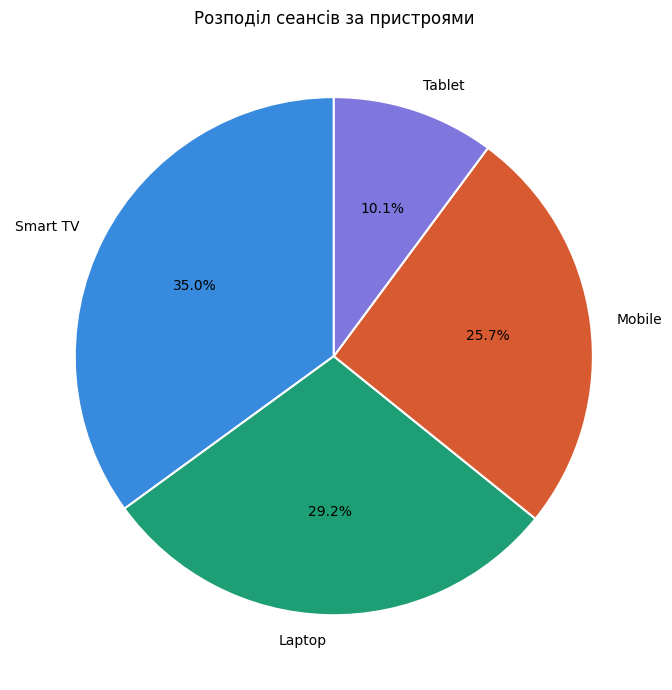

In [140]:
# Завдання 63:
counts = sess["device"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#378ADD", "#1D9E75", "#D85A30", "#7F77DD"],
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)

plt.title("Розподіл сеансів за пристроями")
plt.tight_layout()
plt.show()

**Завдання 64.** Побудуйте графік з розміром 10x6 дюймів через `plt.figure(figsize=...)`. Можна побудувати будь-який — наприклад, кількість сеансів по жанрах.

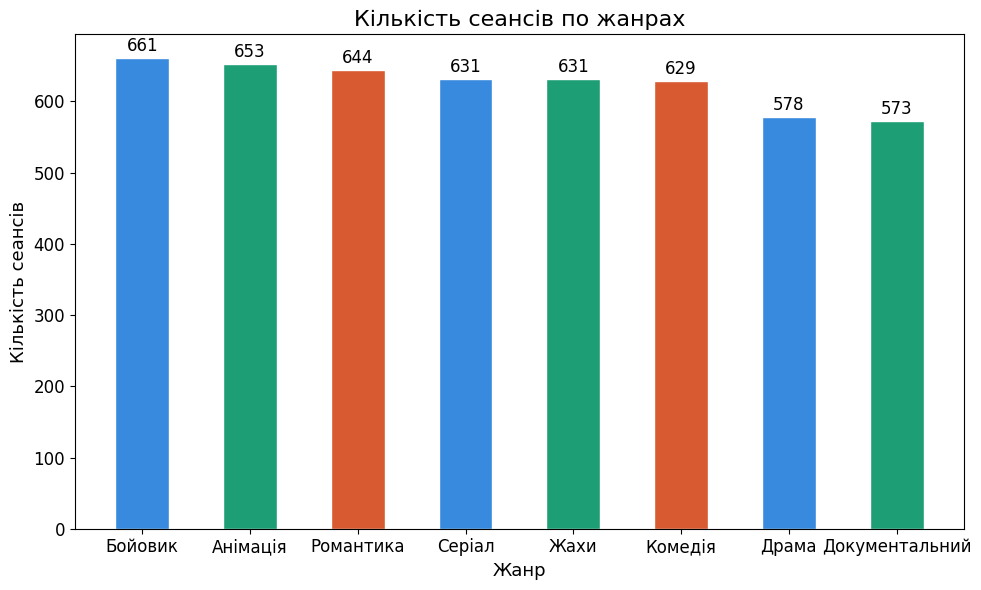

In [141]:
# Завдання 64:
counts = sess["genre"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values,
        color=["#378ADD", "#1D9E75", "#D85A30"],
        edgecolor="white", width=0.5)

plt.title("Кількість сеансів по жанрах", fontsize=16)
plt.xlabel("Жанр", fontsize=13)
plt.ylabel("Кількість сеансів", fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

for i, v in enumerate(counts.values):
    plt.text(i, v + 10, str(v), ha="center", fontsize=12)

plt.tight_layout()
plt.show()

**Завдання 65.** Побудуйте горизонтальну стовпчасту діаграму через `plt.barh()`: кількість сеансів по жанрах.

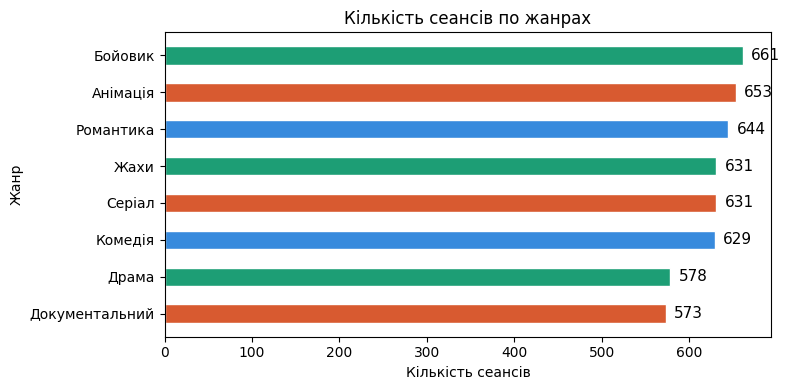

In [142]:
# Завдання 65:
counts = sess["genre"].value_counts().sort_values()

plt.figure(figsize=(8, 4))
plt.barh(counts.index, counts.values,
         color=["#D85A30", "#1D9E75", "#378ADD"],
         edgecolor="white", height=0.5)

plt.title("Кількість сеансів по жанрах")
plt.xlabel("Кількість сеансів")
plt.ylabel("Жанр")

# Підписи значень праворуч від стовпців
for i, v in enumerate(counts.values):
    plt.text(v + 10, i, str(v), va="center", fontsize=11)

plt.tight_layout()
plt.show()

**Завдання 66.** Побудуйте дві гістограми на одній фігурі (виклик `plt.hist` двічі підряд перед `plt.show()`): вік активних підписників та вік неактивних. Використайте параметр `alpha=0.5` для прозорості.

> 💡 `plt.hist(...активні..., alpha=0.5)` потім `plt.hist(...неактивні..., alpha=0.5)` потім `plt.show()`.

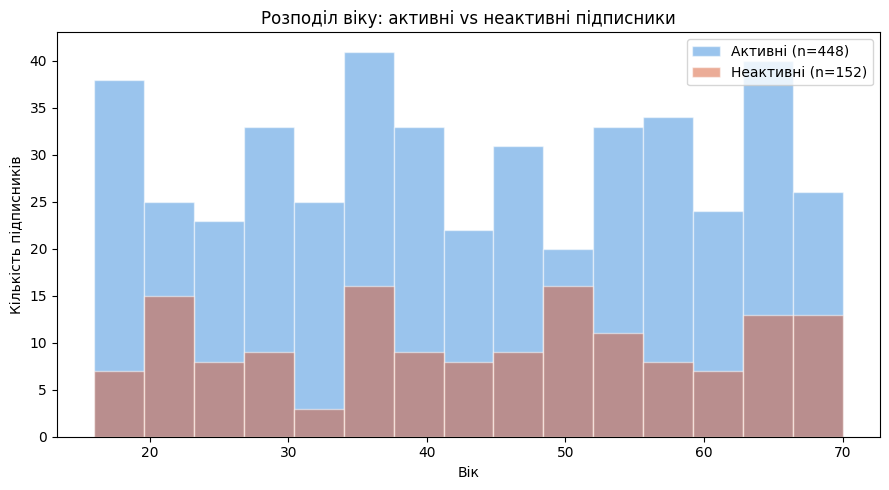

Середній вік активних:   42.9
Середній вік неактивних: 43.8


In [143]:
# Завдання 66:
active   = subs[subs["is_active"] == "Так"]["age"]
inactive = subs[subs["is_active"] == "Ні"]["age"]

plt.figure(figsize=(9, 5))

plt.hist(active,   bins=15, alpha=0.5, color="#378ADD",
         edgecolor="white", label=f"Активні (n={len(active)})")
plt.hist(inactive, bins=15, alpha=0.5, color="#D85A30",
         edgecolor="white", label=f"Неактивні (n={len(inactive)})")

plt.title("Розподіл віку: активні vs неактивні підписники")
plt.xlabel("Вік")
plt.ylabel("Кількість підписників")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Середній вік активних:   {active.mean():.1f}")
print(f"Середній вік неактивних: {inactive.mean():.1f}")

## Розділ 2.3. Налаштування графіків (завдання 67-74)

Тепер додаємо красу і інформативність:
- `plt.title("...")` — заголовок
- `plt.xlabel("...")`, `plt.ylabel("...")` — підписи осей
- `color="..."` — колір (`"red"`, `"#02C39A"`, `"teal"` тощо)
- `plt.xticks(rotation=45)` — повернути підписи по X
- `plt.grid(True)` — додати сітку
- `plt.figure(figsize=(w, h))` — розмір

**Завдання 67.** Побудуйте стовпчасту діаграму кількості підписників по країнах. Додайте заголовок "Кількість підписників по країнах", підпис осі X "Країна" та осі Y "Кількість".

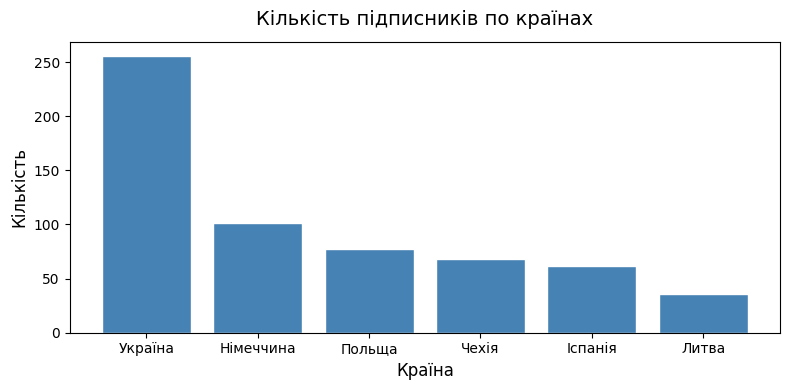

In [144]:
# Завдання 67:
counts = subs["country"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(counts.index, counts.values, color="steelblue", edgecolor="white")

plt.title("Кількість підписників по країнах", fontsize=14, pad=12)
plt.xlabel("Країна", fontsize=12)
plt.ylabel("Кількість", fontsize=12)

plt.tight_layout()
plt.show()

**Завдання 68.** Побудуйте графік середньої тривалості сеансу по жанрах. Усі стовпці зробіть КОЛЬОРОМ `teal`.

> 💡 Параметр `color="teal"` всередині `plt.bar()` або `.plot(kind="bar")`.

In [145]:
# Завдання 68:


NameError: name 'df' is not defined

**Завдання 69.** Побудуйте гістограму віку з 20 інтервалами. Колір — `"#02C39A"` (бірюзовий), додайте заголовок.

In [72]:
# Завдання 69:


**Завдання 70.** Побудуйте діаграму кількості сеансів по місяцях. Підписи на осі X поверніть на 45 градусів.

> 💡 `plt.xticks(rotation=45)`.

In [73]:
# Завдання 70:


**Завдання 71.** Побудуйте стовпчасту діаграму середнього `monthly_fee` по тарифах. Розмір фігури 8x5. Додайте сітку.

> 💡 `plt.grid(True)`. Сітка для bar-діаграм виглядає краще тільки по осі Y: `plt.grid(axis="y")`.

In [74]:
# Завдання 71:


**Завдання 72.** Побудуйте лінійну діаграму кількості сеансів по місяцях. Тип лінії: пунктир, колір червоний, маркери у вигляді крапок.

> 💡 У `plt.plot()` параметри: `linestyle="--"`, `color="red"`, `marker="o"`. Або скорочено: `"r--o"`.

In [75]:
# Завдання 72:


**Завдання 73.** Побудуйте scatter plot: вік (X) vs місячна плата (Y). Колір точок зробіть напівпрозорим (`alpha=0.3`).

In [76]:
# Завдання 73:


**Завдання 74.** Побудуйте кругову діаграму розподілу підписників за тарифами. Покажіть відсотки на кожному секторі.

> 💡 Параметр `autopct="%1.1f%%"` у `plt.pie()`.

In [77]:
# Завдання 74:


## Розділ 2.4. Легенди, кілька серій, subplots (завдання 75-80)

Кілька серій на одному графіку:
- Кожна серія має параметр `label="..."`
- Викликаємо `plt.legend()` — показуємо легенду

Кілька графіків поруч (subplots):
```python
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(...)
axes[0].set_title("Перший")
axes[1].plot(...)
axes[1].set_title("Другий")
plt.show()
```

**Завдання 75.** На одному графіку побудуйте дві лінії: кількість сеансів по місяцях для Smart TV та для Mobile. Додайте легенду з підписами.

> 💡 Двічі викличте `plt.plot(...)` з різними даними, кожен з параметром `label="..."`. Потім `plt.legend()`.

In [78]:
# Завдання 75:


**Завдання 76.** На одному графіку побудуйте дві гістограми віку: окремо для чоловіків і жінок (з прозорістю `alpha=0.5` та різними кольорами). Додайте легенду.

In [79]:
# Завдання 76:


**Завдання 77.** Побудуйте дві стовпчасті діаграми поруч через `subplots(1, 2)`:
- зліва: кількість підписників по країнах
- справа: кількість підписників по тарифах

Кожній додайте заголовок.

In [80]:
# Завдання 77:


**Завдання 78.** Побудуйте 2x2 сітку графіків (`subplots(2, 2)`):
- (0,0): гістограма віку
- (0,1): кількість сеансів по жанрах (bar)
- (1,0): розподіл пристроїв (pie)
- (1,1): середня тривалість по жанрах (barh)

Кожному додайте заголовок. Розмір фігури — 12x10.

> 💡 `fig, axes = plt.subplots(2, 2, figsize=(12, 10))`. Доступ: `axes[0, 0]`, `axes[0, 1]`, `axes[1, 0]`, `axes[1, 1]`.

In [81]:
# Завдання 78:


**Завдання 79.** Побудуйте графік середньої оцінки по жанрах. Стовпці пофарбуйте у РІЗНІ кольори (передайте список кольорів у параметр `color`).

> 💡 `color=["red","blue","green","orange","purple","teal","pink","gray"]` — стільки кольорів, скільки жанрів.

In [82]:
# Завдання 79:


**Завдання 80.** Зробіть фінальний дашборд: 2x1 сітка (один графік над іншим), розмір 10x10.
- зверху: лінійна діаграма кількості сеансів по місяцях, з заголовком "Динаміка переглядів 2024"
- знизу: горизонтальна стовпчаста діаграма топ-10 жанрів за кількістю сеансів, з заголовком "Топ жанрів"

Після всього — `plt.tight_layout()` (виправляє накладання).

> 💡 `fig, axes = plt.subplots(2, 1, figsize=(10, 10))` + наприкінці `plt.tight_layout()`.

In [83]:
# Завдання 80:


---

# 🎉 Готово!

Якщо ви виконали всі 80 завдань — вітаємо! Ви відпрацювали:

**Pandas (50 завдань):**
- ✅ `loc` та `iloc` — потужна вибірка за позицією та умовою
- ✅ Складніший `groupby` з `.agg()`, `.transform()`, групування за кількома стовпцями
- ✅ `pivot_table` — зведені таблиці у стилі Excel
- ✅ Робота з датами (`.dt.month`, `.dt.day_name`, різниця дат)
- ✅ Об'єднання таблиць через `merge`

**Matplotlib (30 завдань):**
- ✅ Швидкі графіки через pandas `.plot()`
- ✅ Базові функції matplotlib: `bar`, `plot`, `hist`, `scatter`, `pie`
- ✅ Налаштування: заголовки, осі, кольори, сітка
- ✅ Легенди та кілька серій на одному графіку
- ✅ Subplots — кілька графіків поруч

### Порада
Найкращий спосіб запам'ятати — повернутись через тиждень і спробувати найскладніші завдання знову, не підглядаючи. **Так тримати! 🐼📊**
